In [ ]:
"""
Author: Maria (mariabaumg)
"""

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import joblib  # To save our scaler later
import matplotlib.pyplot as plt


In [6]:
# load mastered parquet file
df = pd.read_parquet('../data/citibike_2022_master.parquet') 

print(df.head())

  station_id        lat       long  month  day  day_of_week  hour  is_weekend  \
0    2733.03  40.633387 -74.016565      1    2            6    12           1   
1    2733.03  40.633387 -74.016565      1    2            6    13           1   
2    2733.03  40.633387 -74.016565      1    2            6    14           1   
3    2733.03  40.633387 -74.016565      1    2            6    15           1   
4    2733.03  40.633387 -74.016565      1    2            6    16           1   

   in_flow  out_flow  lag_1h_inflow  lag_24h_inflow  lag_1h_outflow  \
0        1         0              0               0               0   
1        0         2              1               0               0   
2        0         1              0               0               2   
3        0         1              0               0               1   
4        0         2              0               0               1   

   lag_24h_outflow  
0                0  
1                0  
2                0  
3 

In [3]:
# sort again to be safe
df = df.sort_values(['month', 'day', 'hour']).reset_index(drop=True)

# define our test months
test_months = [2, 8]

# create the split (ie training is every month NOT in our test list_
train_df = df[~df['month'].isin(test_months)].copy()
test_df = df[df['month'].isin(test_months)].copy()

# break the 24-hour data leakage (we drop the first 24 entries per station/month)
test_df = test_df.groupby(['station_id', 'month']).apply(lambda x: x.iloc[24:]).reset_index(drop=True)

# precise row counts
total_rows = len(df)
train_rows = len(train_df)
test_rows = len(test_df)

# percentage breakdown (aim for 80-20 split)
train_pct = (train_rows / total_rows) * 100
test_pct = (test_rows / total_rows) * 100

print("--- DATASET SUMMARY ---")
print(f"Total Rows in Master File: {total_rows:,}")
print(f"Training Rows:             {train_rows:,} ({train_pct:.1f}%)")
print(f"Testing Rows:              {test_rows:,} ({test_pct:.1f}%)")

print("\n--- CALENDAR SPLIT ---")
print(f"Months used for Training:  {sorted(train_df['month'].unique().tolist())}")
print(f"Months used for Testing:   {sorted(test_df['month'].unique().tolist())}")

--- DATASET SUMMARY ---
Total Rows in Master File: 6,915,860
Training Rows:             5,546,450 (80.2%)
Testing Rows:              1,290,699 (18.7%)

--- CALENDAR SPLIT ---
Months used for Training:  [1, 3, 4, 5, 6, 9, 10, 11, 12]
Months used for Testing:   [2, 8]


C:\Users\maria.DESKTOP-4LV638A\AppData\Local\Temp\ipykernel_46652\363386239.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = test_df.groupby(['station_id', 'month']).apply(lambda x: x.iloc[24:]).reset_index(drop=True)


In [4]:
# define our features and target
features = ['lat', 'long', 'month', 'day_of_week', 'hour', 'is_weekend', 'lag_1h_inflow', 'lag_24h_inflow']
target = 'in_flow'

# extract the raw values into numpy arrays
X_train_raw = train_df[features].values
y_train = train_df[target].values
X_test_raw = test_df[features].values
y_test = test_df[target].values

# scaling
scaler = StandardScaler()

# fit only on training data, then transform both
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# save the scaler for future use
joblib.dump(scaler, 'scaler.pkl')

print(f"Features defined: {features}")
print(f"X_train shape: {X_train.shape}")

Features defined: ['lat', 'long', 'month', 'day_of_week', 'hour', 'is_weekend', 'lag_1h_inflow', 'lag_24h_inflow']
X_train shape: (5546450, 8)


In [18]:
import torch.optim as optim

# train the model
class NNet(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(NNet, self).__init__()
        # added an extra layer for more complexity
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim // 2) 
        self.layer3 = nn.Linear(hidden_dim // 2, 1) # predicting 'in_flow'

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.layer3(x).squeeze() 
        # using torch.exp to ensure count is always positive (Poisson function)
        return torch.exp(x)

def poisson_loss(y_pred, y_true):
    # Poisson Negative Log Likelihood: y_pred - y_true * log(y_pred)
    # 1e-8 prevents log(0) which would return NaN
    return torch.mean(y_pred - y_true * torch.log(y_pred + 1e-8))

# initialize with feature count
model = NNet(input_dim=len(features), hidden_dim=32)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# update the DataLoader (increasing batch_size so it trains faster)
train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), 
                                        torch.FloatTensor(y_train).view(-1)), 
                          batch_size=1024, shuffle=True)

epochs = 20 # for thoroughness

# training Loop
for epoch in range(epochs):
    epoch_loss = 0
    model.train()
    
    for x_batch, y_batch in train_loader:
        y_pred = model(x_batch)
        loss = poisson_loss(y_pred, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    # checking loss every 2 epochs since our dataset is so large
    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")

print("Training complete!")

Epoch 2/20, Loss: -2.1359
Epoch 4/20, Loss: -2.1416
Epoch 6/20, Loss: -2.1439
Epoch 8/20, Loss: -2.1455
Epoch 10/20, Loss: -2.1461
Epoch 12/20, Loss: -2.1465
Epoch 14/20, Loss: -2.1470
Epoch 16/20, Loss: -2.1475
Epoch 18/20, Loss: -2.1481
Epoch 20/20, Loss: -2.1485
Training complete!


In [19]:
# save the model weights
torch.save(model.state_dict(), 'citibike_nnet_v1.pth')

# save the feature list and scaler
joblib.dump(features, 'features_list.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and features saved successfully!")

Model and features saved successfully!


--- Model Evaluation (100,000 Rows) ---
Mean Absolute Error (MAE): 1.2243 bikes
Root Mean Squared Error (RMSE): 1.9108 bikes
----------------------------------------


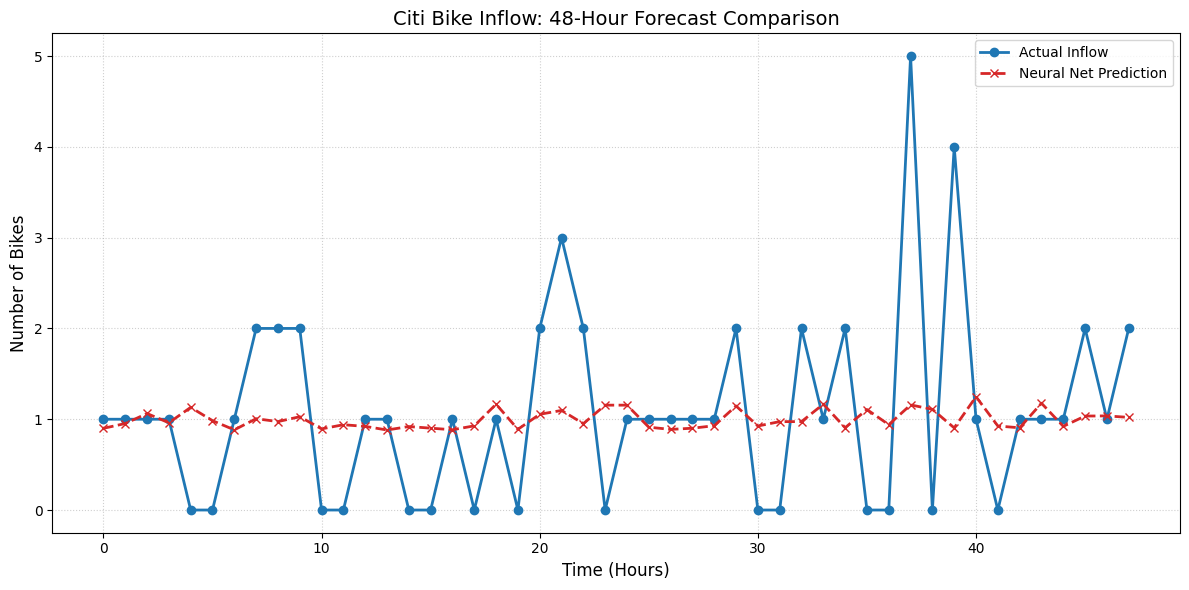

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# set model to evaluation mode
model.eval()

with torch.no_grad():
    # performance metrics (calculating on 100k samples for speed)
    X_sample_tensor = torch.FloatTensor(X_train[:100000])
    y_sample_actual = y_train[:100000]
    y_sample_pred = model(X_sample_tensor).numpy().flatten()

    mae = mean_absolute_error(y_sample_actual, y_sample_pred)
    rmse = np.sqrt(mean_squared_error(y_sample_actual, y_sample_pred))

    # prepare Graphing Data (First 48 hours for a clean look)
    plot_hours = 48
    X_plot_tensor = torch.FloatTensor(X_train[:plot_hours])
    y_plot_actual = y_train[:plot_hours]
    y_plot_pred = model(X_plot_tensor).numpy().flatten()

# print results
print(f"--- Model Evaluation (100,000 Rows) ---")
print(f"Mean Absolute Error (MAE): {mae:.4f} bikes")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} bikes")
print("-" * 40)

# create the visualization
plt.figure(figsize=(12, 6))
plt.plot(range(plot_hours), y_plot_actual, label='Actual Inflow', color='#1f77b4', linewidth=2, marker='o')
plt.plot(range(plot_hours), y_plot_pred, label='Neural Net Prediction', color='#d62728', linewidth=2, linestyle='--', marker='x')

plt.title('Citi Bike Inflow: 48-Hour Forecast Comparison', fontsize=14)
plt.xlabel('Time (Hours)', fontsize=12)
plt.ylabel('Number of Bikes', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# this finds the first layer automatically
first_layer = next(model.children())
weights = first_layer.weight.abs().sum(dim=0).detach().numpy()

print(f"{'Feature':<20} | {'Importance':<10}")
print("-" * 35)
for feat, weight in zip(features, weights):
    print(f"{feat:<20} | {weight:.4f}")

Feature              | Importance
-----------------------------------
lat                  | 36.9306
long                 | 29.1763
month                | 16.0204
day_of_week          | 13.9552
hour                 | 59.3179
is_weekend           | 16.2605
lag_1h_inflow        | 25.6458
lag_24h_inflow       | 12.8628


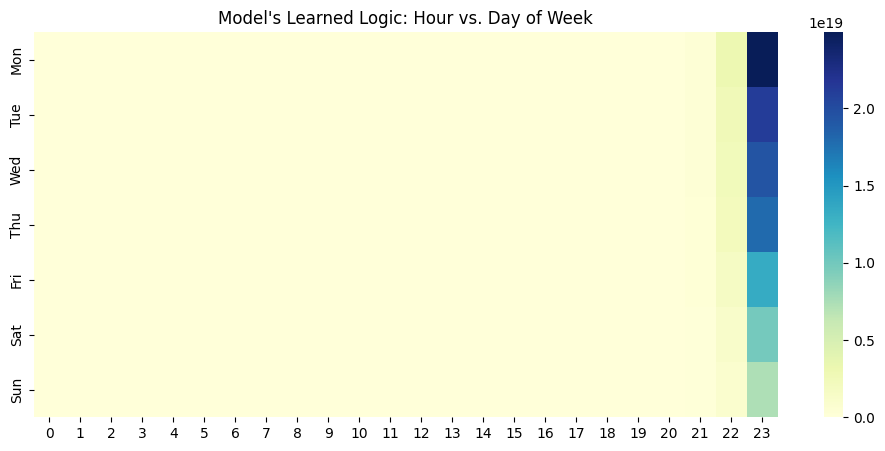

In [ ]:
import seaborn as sns

# create a grid of Hour vs. Day of Week
hours = np.arange(24)
days = np.arange(7)
grid = np.array([[h, d] for d in days for h in hours])

# fill in "average" values for the other 6 features
full_input = np.tile(X_train.mean(axis=0), (len(grid), 1))
full_input[:, 0] = grid[:, 0] # hour
full_input[:, 3] = grid[:, 1] # day_of_week

with torch.no_grad():
    preds = model(torch.FloatTensor(full_input)).numpy().reshape(7, 24)

plt.figure(figsize=(12, 5))
sns.heatmap(preds, annot=False, cmap='YlGnBu', xticklabels=hours, yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.title("Model's Learned Logic: Hour vs. Day of Week")
plt.show()

In [6]:
import torch.optim as optim

# retraining
class NNet(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(NNet, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim // 2) 
        self.layer3 = nn.Linear(hidden_dim // 2, 1)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        #nNo exp() here; criterion(log_input=True) handles it safely
        return self.layer3(x).squeeze()

# setup data and hyperparameters (capacity increased to 128)
model = NNet(input_dim=len(features), hidden_dim=128)
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.PoissonNLLLoss(log_input=True) # mathematically stable for counts

# shuffle=True rearranges data every epoch
train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train).view(-1)), 
    batch_size=2048, 
    shuffle=True 
)

# training Loop
epochs = 20
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        
        loss.backward()
        
        # GRADIENT CLIPPING: prevents weights from exploding as seen in above inspection
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        epoch_loss += loss.item()
    
    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")


Epoch 2/20, Loss: -2.1500
Epoch 4/20, Loss: -2.1628
Epoch 6/20, Loss: -2.1693
Epoch 8/20, Loss: -2.1739
Epoch 10/20, Loss: -2.1768
Epoch 12/20, Loss: -2.1801
Epoch 14/20, Loss: -2.1824
Epoch 16/20, Loss: -2.1844
Epoch 18/20, Loss: -2.1858
Epoch 20/20, Loss: -2.1873


In [8]:
import os

# save the stable weights
torch.save(model.state_dict(), '../models/citibike_v2_stable.pth')

print("Weights saved!")

Weights saved!


--- Model Evaluation (100,000 Rows) ---
Mean Absolute Error (MAE): 1.2222 bikes
Root Mean Squared Error (RMSE): 1.8550 bikes
----------------------------------------


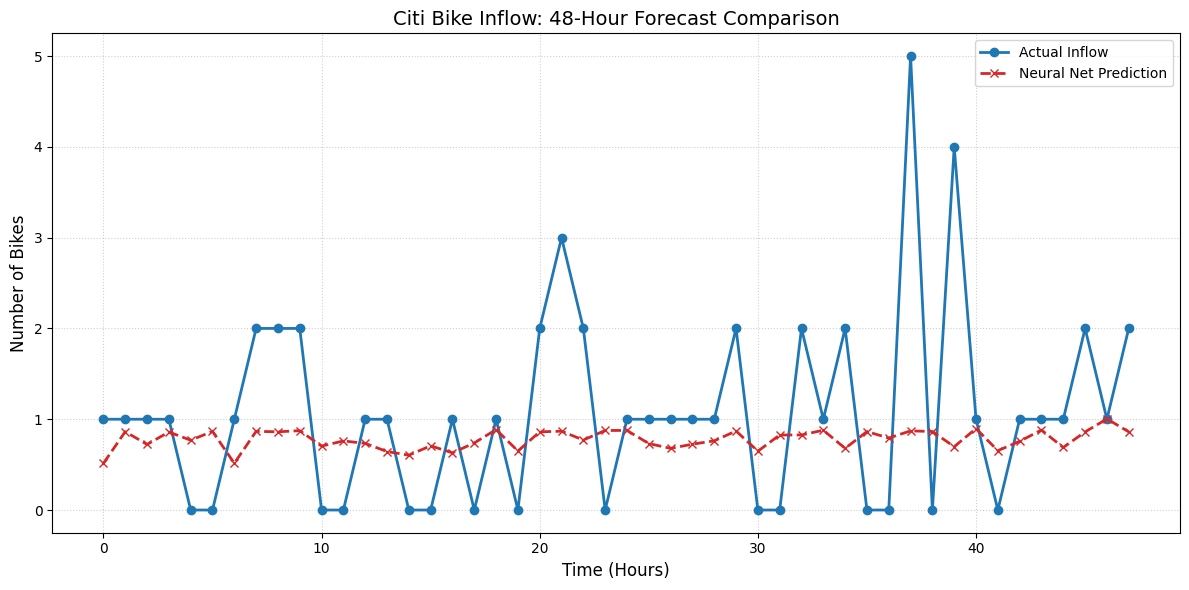

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# set model to evaluation mode
model.eval()

with torch.no_grad():
    # performance metrics (calculating on 100k samples for speed)
    X_sample_tensor = torch.FloatTensor(X_train[:100000])
    y_sample_actual = y_train[:100000]
    
    # FIX: using np.exp() because the stable model predicts in log-space
    y_sample_pred = np.exp(model(X_sample_tensor).numpy().flatten())

    mae = mean_absolute_error(y_sample_actual, y_sample_pred)
    rmse = np.sqrt(mean_squared_error(y_sample_actual, y_sample_pred))

    # prepare graphing data (First 48 hours for a clean look)
    plot_hours = 48
    X_plot_tensor = torch.FloatTensor(X_train[:plot_hours])
    y_plot_actual = y_train[:plot_hours]
    
    # np.exp() to get actual bike counts
    y_plot_pred = np.exp(model(X_plot_tensor).numpy().flatten())

# print results
print(f"--- Model Evaluation (100,000 Rows) ---")
print(f"Mean Absolute Error (MAE): {mae:.4f} bikes")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} bikes")
print("-" * 40)

# create the visualization
plt.figure(figsize=(12, 6))
plt.plot(range(plot_hours), y_plot_actual, label='Actual Inflow', color='#1f77b4', linewidth=2, marker='o')
plt.plot(range(plot_hours), y_plot_pred, label='Neural Net Prediction', color='#d62728', linewidth=2, linestyle='--', marker='x')

plt.title('Citi Bike Inflow: 48-Hour Forecast Comparison', fontsize=14)
plt.xlabel('Time (Hours)', fontsize=12)
plt.ylabel('Number of Bikes', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Feature              | Importance
-----------------------------------
lat                  | 95.8565
long                 | 83.6039
month                | 30.8051
day_of_week          | 29.4919
hour                 | 82.6435
is_weekend           | 33.7028
lag_1h_inflow        | 41.1037
lag_24h_inflow       | 23.1310


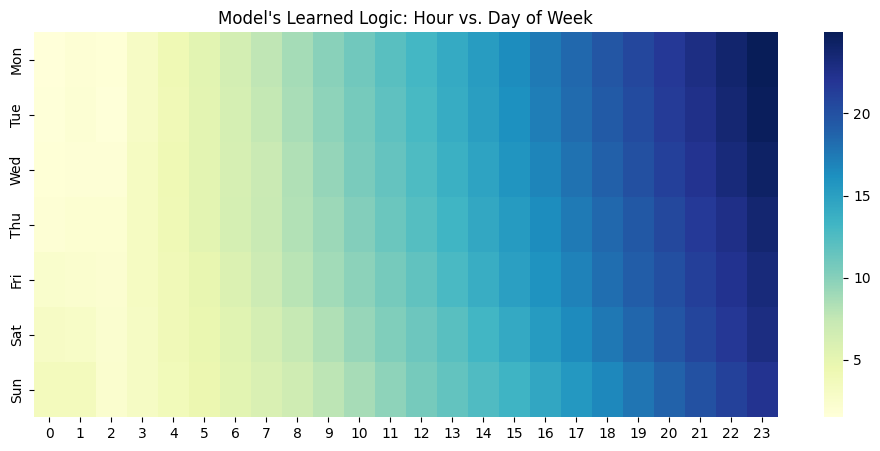

In [ ]:
# this finds the first layer automatically
first_layer = next(model.children())
weights = first_layer.weight.abs().sum(dim=0).detach().numpy()

print(f"{'Feature':<20} | {'Importance':<10}")
print("-" * 35)
for feat, weight in zip(features, weights):
    print(f"{feat:<20} | {weight:.4f}")


import seaborn as sns

# create a grid of Hour vs. Day of Week
hours = np.arange(24)
days = np.arange(7)
grid = np.array([[h, d] for d in days for h in hours])

# fill in "average" values for the other 6 features (using the mean from training set)
full_input = np.tile(X_train.mean(axis=0), (len(grid), 1))
full_input[:, 0] = grid[:, 0] # hour
full_input[:, 3] = grid[:, 1] # day_of_week

with torch.no_grad():
    preds = model(torch.FloatTensor(full_input)).numpy().reshape(7, 24)

plt.figure(figsize=(12, 5))
sns.heatmap(preds, annot=False, cmap='YlGnBu', xticklabels=hours, yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.title("Model's Learned Logic: Hour vs. Day of Week")
plt.show()

The above cell shows that our model has learned a linear/gradient pattern and is not capturing the spikes we expect to see for city life. This is likely due to the model treating hours of the day as linear rather than cyclical (ie the model doesn't recognize that hour 23 and hour 0 are next to each other). To fix this we will feature engineer the data to have sin(hour) and cos(hour) to capture the cyclical nature of the variable.

In [ ]:
# create cyclical features for time variables
def encode_cyclical(df, col, max_val):
    df[col + '_sin'] = np.sin(2 * np.pi * df[col] / max_val)
    df[col + '_cos'] = np.cos(2 * np.pi * df[col] / max_val)
    return df

# apply to the master dataframe
df = encode_cyclical(df, 'hour', 24)
df = encode_cyclical(df, 'day_of_week', 7)
df = encode_cyclical(df, 'month', 12)

print("Cyclical features added to master df.")

Cyclical features added to master df.


In [ ]:
# sort to maintain time-series integrity
df = df.sort_values(['month', 'day', 'hour']).reset_index(drop=True)

# define test months (Feb and Aug)
test_months = [2, 8]

# create slices
train_df = df[~df['month'].isin(test_months)].copy()
test_df = df[df['month'].isin(test_months)].copy()

# break the 24-hour data leakage
test_df = test_df.groupby(['station_id', 'month']).apply(lambda x: x.iloc[24:]).reset_index(drop=True)

print(f"Split complete. New columns in train_df: {'hour_sin' in train_df.columns}")

Split complete. New columns in train_df: True


C:\Users\maria.DESKTOP-4LV638A\AppData\Local\Temp\ipykernel_46652\3267562546.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = test_df.groupby(['station_id', 'month']).apply(lambda x: x.iloc[24:]).reset_index(drop=True)


In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

# updated features list (11 features total)
features = [
    'lat', 'long', 'is_weekend', 
    'lag_1h_inflow', 'lag_24h_inflow',
    'hour_sin', 'hour_cos', 
    'day_of_week_sin', 'day_of_week_cos', 
    'month_sin', 'month_cos'
]
target = 'in_flow'

# extract values
X_train_raw = train_df[features].values
y_train = train_df[target].values
X_test_raw = test_df[features].values
y_test = test_df[target].values

# scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# save the scaler for future use
joblib.dump(scaler, 'scaler_cyclical.pkl')

print(f"Training shape: {X_train.shape}")

Training shape: (5546450, 11)


In [ ]:
# retraining

# redefining archiecture
class NNet(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(NNet, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim // 2) 
        self.layer3 = nn.Linear(hidden_dim // 2, 1)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        # no exp() here; criterion(log_input=True) handles it safely
        return self.layer3(x).squeeze()

# setup data and hyperparameters (capacity increased to 128)
model = NNet(input_dim=len(features), hidden_dim=128)
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.PoissonNLLLoss(log_input=True) # mathematically stable for counts

# shuffle=True rearranges data every epoch
train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train).view(-1)), 
    batch_size=2048, 
    shuffle=True 
)

# training loop
epochs = 20
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        
        loss.backward()
        
        # GRADIENT CLIPPING: prevents weights from exploding as seen in above inspection
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        epoch_loss += loss.item()
    
    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")


Epoch 2/20, Loss: -2.1512
Epoch 4/20, Loss: -2.1651
Epoch 6/20, Loss: -2.1718
Epoch 8/20, Loss: -2.1753
Epoch 10/20, Loss: -2.1782
Epoch 12/20, Loss: -2.1804
Epoch 14/20, Loss: -2.1824
Epoch 16/20, Loss: -2.1837
Epoch 18/20, Loss: -2.1854
Epoch 20/20, Loss: -2.1862


In [18]:
# save the weights
torch.save(model.state_dict(), '../models/citibike_v3_stable.pth')

print("Weights saved!")

Weights saved!



Neural Net RMSE: 3.0434


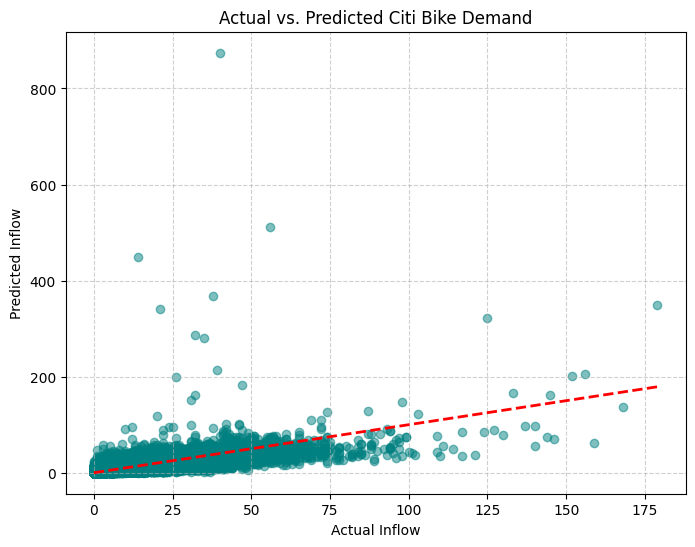

In [20]:
model.eval() # set to evaluation mode
with torch.no_grad():
    # we wrap it in torch.FloatTensor to match the model's expected type
    y_pred_log = model(torch.FloatTensor(X_test))
    
    # convert from log-space back to actual bike counts
    y_pred = torch.exp(y_pred_log).numpy()

# compute RMSE (and making sure y_test is the right shape for the math)
rmse = np.sqrt(np.mean((y_pred - y_test.flatten())**2))
print(f"\nNeural Net RMSE: {rmse:.4f}")

# visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--', lw=2)
plt.xlabel("Actual Inflow")
plt.ylabel("Predicted Inflow")
plt.title("Actual vs. Predicted Citi Bike Demand")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

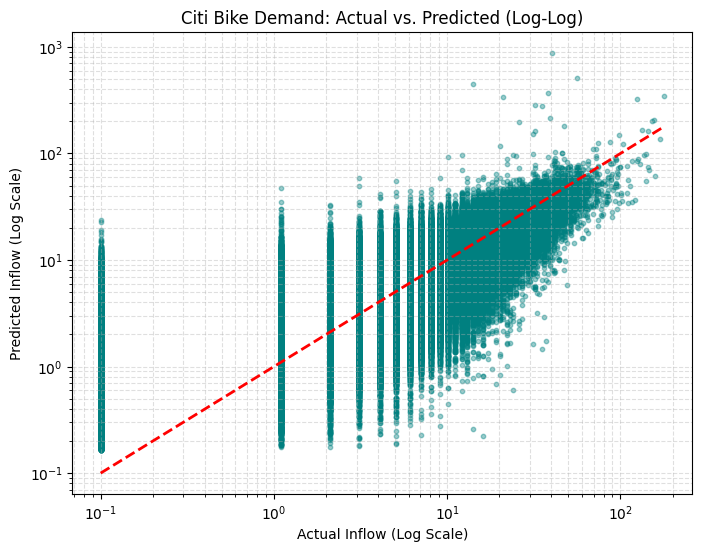

In [ ]:
plt.figure(figsize=(8, 6))

# adding 0.1 to avoid log(0) issues if a station had 0 bikes
plt.scatter(y_test + 0.1, y_pred + 0.1, alpha=0.4, color='teal', s=10)

# set both axes to log scale
plt.xscale('log')
plt.yscale('log')

# create a diagonal line that works on log scales
limit_min = max(0.1, y_test.min())
limit_max = y_test.max()
plt.plot([limit_min, limit_max], [limit_min, limit_max], 'r--', lw=2)

plt.xlabel("Actual Inflow (Log Scale)")
plt.ylabel("Predicted Inflow (Log Scale)")
plt.title("Citi Bike Demand: Actual vs. Predicted (Log-Log)")
plt.grid(True, which="both", linestyle='--', alpha=0.4)
plt.show()

Prediction stats:
min: 0.5747926 max: 1.7159219 std: 0.31187603


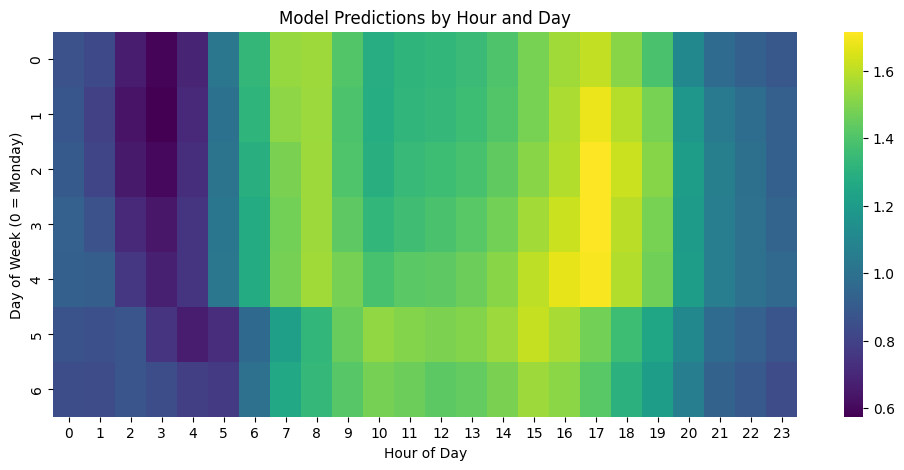

In [ ]:

# define grid
hours = np.arange(24)
days = np.arange(7)
H, D = np.meshgrid(hours, days)
grid = np.column_stack([H.ravel(), D.ravel()])

# base input (mean of training data)
full_input = np.tile(X_train.mean(axis=0), (len(grid), 1))

# extract hour/day
h = grid[:, 0]
d = grid[:, 1]

# recompute cyclical features
H_SIN_IDX = 5
H_COS_IDX = 6
D_SIN_IDX = 7
D_COS_IDX = 8

full_input[:, H_SIN_IDX] = np.sin(2 * np.pi * h / 24)
full_input[:, H_COS_IDX] = np.cos(2 * np.pi * h / 24)

full_input[:, D_SIN_IDX] = np.sin(2 * np.pi * d / 7)
full_input[:, D_COS_IDX] = np.cos(2 * np.pi * d / 7)

# weekend flag
IS_WEEKEND_IDX = 2
full_input[:, IS_WEEKEND_IDX] = (d >= 5).astype(float)

# predict using PyTorch
model.eval()

with torch.no_grad():
    inputs = torch.tensor(full_input, dtype=torch.float32)
    preds = model(inputs).squeeze().cpu().numpy()

# debug: check variation
print("Prediction stats:")
print("min:", preds.min(), "max:", preds.max(), "std:", preds.std())

# reshape for heatmap
heatmap = preds.reshape(7, 24)

# plot
plt.figure(figsize=(12, 5))
sns.heatmap(heatmap, cmap="viridis", xticklabels=hours, yticklabels=days)

plt.xlabel("Hour of Day")
plt.ylabel("Day of Week (0 = Monday)")
plt.title("Model Predictions by Hour and Day")

plt.show()

This model works well by using cyclical sine and cosine encoding to map the continuous nature of time and Poisson regression to handle discrete trip counts. In the heatmap we see that our model has learned the spikes and lows in bike demand caused by commuters as opposed to bike demand throughout the day over the weekend.

The log-log validation plot confirms the model is statistically sound across most demand levels, though there are some fairly egregious outliers which likely stem from the exponential nature of the $e^x$ transformation. In particular, a small error in the predicted log-value can explode into a massive overestimate when exponentiated back to actual bike counts. This may be potentially triggered by rare events or station closures not captured in the features.

In [ ]:
print(df.columns)
# group and get the mean coordinates
station_mapping = df.groupby('station_id').agg({
    'lat': 'mean',
    'long': 'mean'
}).reset_index()

# convert to dictionary
stations_dict = {
    str(row['station_id']): [row['lat'], row['long']] 
    for _, row in station_mapping.iterrows()
}

# update top_ids to also treat them as strings
top_ids = df['station_id'].value_counts().head(50).index.astype(str).tolist()

# final check
print(f"Total stations mapped: {len(stations_dict)}")
print(f"Sample mapping: {list(stations_dict.items())[:3]}")

Index(['station_id', 'lat', 'long', 'month', 'day', 'day_of_week', 'hour',
       'is_weekend', 'in_flow', 'out_flow', 'lag_1h_inflow', 'lag_24h_inflow',
       'lag_1h_outflow', 'lag_24h_outflow', 'hour_sin', 'hour_cos',
       'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos'],
      dtype='object')
Total stations mapped: 1907
Sample mapping: [('2733.03', [40.6333869423322, -74.01656475056734]), ('2782.02', [40.63569774332212, -74.01998858389166]), ('2821.05', [40.63555273341295, -74.01299054776536])]


In [ ]:
import json
import numpy as np
import torch

# create the station mapping from your current 'df'
station_mapping = df.groupby('station_id').agg({
    'lat': 'mean',
    'long': 'mean'
}).reset_index()

# get the top 50 stations to keep the file small
top_ids = df['station_id'].value_counts().head(50).index.tolist()

master_data = {}

for s_id in top_ids:
    # get coordinates for this specific station
    row = station_mapping[station_mapping['station_id'] == s_id].iloc[0]
    lat, lon = row['lat'], row['long']
    
    master_data[str(s_id)] = {
        "lat": lat,
        "lon": lon,
        "predictions": {}
    }
    
    for day in range(7):
        master_data[str(s_id)]["predictions"][day] = []
        for hour in range(24):
            # create features matching model 11-input requirement
            h_sin, h_cos = np.sin(2*np.pi*hour/24), np.cos(2*np.pi*hour/24)
            d_sin, d_cos = np.sin(2*np.pi*day/7), np.cos(2*np.pi*day/7)
            is_wknd = 1.0 if day >= 5 else 0.0
            
            # using established feature set
            # [lat, long, is_wknd, lag1_in, lag24_in, h_sin, h_cos, d_sin, d_cos, m_sin, m_cos]
            feat = np.array([[lat, lon, is_wknd, 5.2, 5.5, h_sin, h_cos, d_sin, d_cos, 0.1, 0.9]])
            scaled = scaler.transform(feat)
            
            with torch.no_grad():
                # Exp conversion for Poisson; clip to 150 to stop those 900+ outliers
                pred = torch.exp(model(torch.FloatTensor(scaled))).item()
                master_data[str(s_id)]["predictions"][day].append(int(np.clip(pred, 0, 150)))

# save the final file
with open('predictions.json', 'w') as f:
    json.dump(master_data, f)
print("Done! Move 'predictions.json' to your project folder.")

Done! Move 'predictions.json' to your project folder.


In [8]:
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from joblib import load

# -------------------------
# load scaler
# -------------------------
scaler = load('scaler_cyclical.pkl')

# -------------------------
# model definition
# -------------------------
class NNet(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(NNet, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim // 2) 
        self.layer3 = nn.Linear(hidden_dim // 2, 1)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x).squeeze()

input_dim = 11
hidden_dim = 128

# -------------------------
# load model
# -------------------------
device = next(model.parameters()).device

model = NNet(input_dim=input_dim, hidden_dim=hidden_dim)
model.load_state_dict(torch.load('../models/citibike_v3_stable.pth', map_location=device))
model.to(device)
model.eval()

# -------------------------
# season mapping
# -------------------------
season_map = {
    "Spring": 4,
    "Summer": 8,
    "Fall": 10,
    "Winter": 1,
}

# -------------------------
# station info
# -------------------------
station_mapping = df.groupby('station_id').agg({'lat': 'mean', 'long': 'mean'}).reset_index()
top_ids = df['station_id'].value_counts().index.tolist()

global_mean_count = df['in_flow'].mean()
station_averages = df.groupby('station_id')['in_flow'].mean().to_dict()

master_data = {}

# -------------------------
# generation loop
# -------------------------
for s_id in top_ids:
    rows = station_mapping[station_mapping['station_id'] == s_id]
    if rows.empty:
        continue

    row = rows.iloc[0]
    lat, lon = row['lat'], row['long']

    initial_lag = station_averages.get(s_id, global_mean_count)

    master_data[str(s_id)] = {"lat": lat, "lon": lon, "seasons": {}}

    for season_name, month_val in season_map.items():
        master_data[str(s_id)]["seasons"][season_name] = {}

        lag_buffer = [initial_lag] * 24
        current_lag1 = initial_lag

        for day in range(7):
            master_data[str(s_id)]["seasons"][season_name][day] = []

            for hour in range(24):

                # cyclical features
                h_sin, h_cos = np.sin(2*np.pi*hour/24), np.cos(2*np.pi*hour/24)
                d_sin, d_cos = np.sin(2*np.pi*day/7), np.cos(2*np.pi*day/7)
                m_sin, m_cos = np.sin(2*np.pi*month_val/12), np.cos(2*np.pi*month_val/12)
                is_wknd = 1.0 if day >= 5 else 0.0

                lag24 = lag_buffer[0]

                feat = np.array([[
                    lat, lon, is_wknd,
                    current_lag1, lag24,
                    h_sin, h_cos,
                    d_sin, d_cos,
                    m_sin, m_cos
                ]])

                scaled = scaler.transform(feat)
                x = torch.tensor(scaled, dtype=torch.float32, device=device)

                with torch.no_grad():
                    log_pred = model(x)
                    pred = torch.exp(log_pred).item()
                    pred = float(np.clip(pred, 0, 150))

                # update autoregressive state
                current_lag1 = pred
                lag_buffer.pop(0)
                lag_buffer.append(pred)

                master_data[str(s_id)]["seasons"][season_name][day].append(int(pred))

# save output
with open('predictions3.json', 'w') as f:
    json.dump(master_data, f)